In [0]:
import mlflow

# Find the run ID and use the artifact URI
model_uri = "runs:/e6627384abb243bb82450fccbf4bc0cd/random_forest_model"
rf_model = mlflow.spark.load_model(
    model_uri, dfs_tmpdir="/Volumes/workspace/codebasics/gold/mlflow_staging"
)

In [0]:
train_df = spark.read.load("/Volumes/workspace/codebasics/gold/train_df")

In [0]:
from pyspark.ml.classification import RandomForestClassificationModel
from pyspark.ml.regression import RandomForestRegressionModel

rf_stage = None
for stage in rf_model.stages:
    if isinstance(stage, (RandomForestClassificationModel, RandomForestRegressionModel)):
        rf_stage = stage
        break

if rf_stage is None:
    raise ValueError("No RandomForest model found in pipeline stages.")


---

## ✨ Checking Feature Importance:

INFO:py4j.clientserver:Received command c on object id p0
/home/spark-1b83a038-c48a-4f08-b0a8-41/.ipykernel/2568/command-6244847922682030-2405322330:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=importance_df, palette="magma")


--- Top 10 Features Driving Customer Spending ---
                       Feature  Importance
0                          Age    0.268759
3           State_names_target    0.261500
1                     Referral    0.048644
5              Gender_vec_Male    0.035213
17   Payment_method_vec_PayPal    0.033581
7    Marital_status_vec_Single    0.031643
6   Marital_status_vec_Married    0.031512
18     Payment_method_vec_Card    0.030883
19    Payment_method_vec_Other    0.029920
4            Gender_vec_Female    0.027020


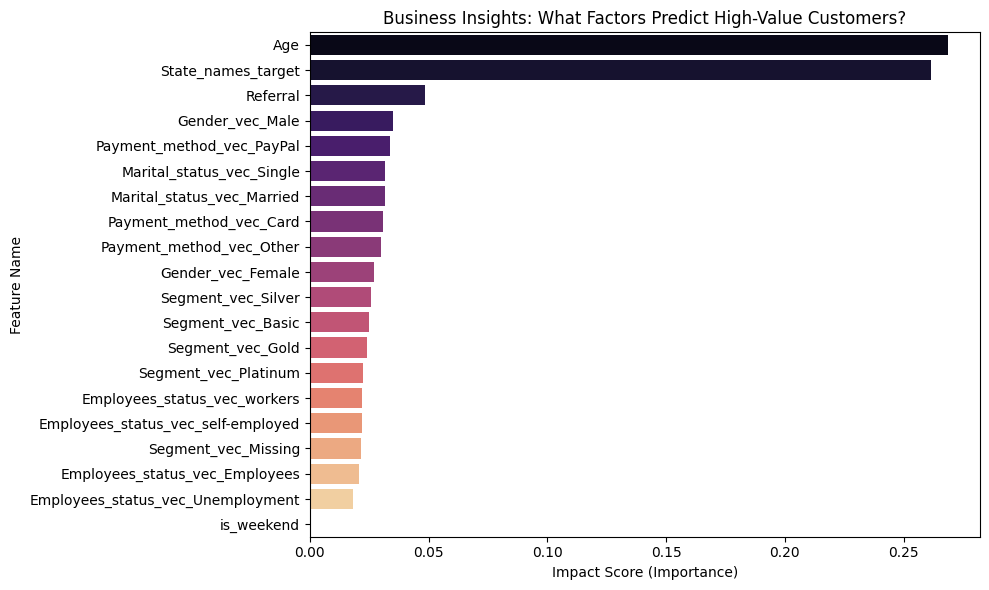

In [0]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Extract Feature Importance scores
importances = rf_stage.featureImportances

# 2. Extract Feature Names from VectorAssembler Metadata
# This shows high technical proficiency with Spark
attrs = train_df.schema["features"].metadata["ml_attr"]["attrs"]
feature_names = []

# Collect names from numeric and binary attribute groups
for group in attrs.values():
    for attr in group:
        feature_names.append((attr["idx"], attr["name"]))

# Sort names to match the importance vector index
feature_names.sort(key=lambda x: x[0])
sorted_names = [x[1] for x in feature_names]

# 3. Create a DataFrame for analysis
importance_df = pd.DataFrame({
    "Feature": sorted_names,
    "Importance": importances.toArray()
}).sort_values(by="Importance", ascending=False)

# 4. Display the Top Business Drivers
print("--- Top 10 Features Driving Customer Spending ---")
print(importance_df.head(10))

# 5. Visualize (Save this for your presentation!)
plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=importance_df, palette="magma")
plt.title("Business Insights: What Factors Predict High-Value Customers?")
plt.xlabel("Impact Score (Importance)")
plt.ylabel("Feature Name")
plt.tight_layout()
plt.savefig("/Volumes/workspace/codebasics/gold/feature_importance.png")
plt.show()

---

## 🪙 Preparing the Business-Ready (Gold) Data
We select the key columns and extract the `Max Probability` to show how confident the AI is.

In [0]:
test_df = spark.read.load("/Volumes/workspace/codebasics/gold/test_df")

In [0]:
predictions = rf_stage.transform(test_df)
display(predictions)

features,value_segment,rawPrediction,probability,prediction
"{""type"":""0"",""size"":""20"",""indices"":[""0"",""1"",""2"",""3"",""4"",""6"",""8"",""13"",""17""],""values"":[""15.0"",""1.0"",""1.0"",""1348.7624296296137"",""1.0"",""1.0"",""1.0"",""1.0"",""1.0""]}",2,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""39.14498193442636"",""29.924855992162108"",""30.93016207341152""]}","{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.39144981934426365"",""0.29924855992162114"",""0.30930162073411527""]}",0.0
"{""type"":""0"",""size"":""20"",""indices"":[""0"",""1"",""2"",""3"",""4"",""6"",""8"",""13"",""17""],""values"":[""15.0"",""1.0"",""1.0"",""1348.7624296296137"",""1.0"",""1.0"",""1.0"",""1.0"",""1.0""]}",2,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""39.14498193442636"",""29.924855992162108"",""30.93016207341152""]}","{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.39144981934426365"",""0.29924855992162114"",""0.30930162073411527""]}",0.0
"{""type"":""0"",""size"":""20"",""indices"":[""0"",""1"",""2"",""3"",""4"",""6"",""8"",""13"",""17""],""values"":[""15.0"",""1.0"",""1.0"",""1348.7624296296137"",""1.0"",""1.0"",""1.0"",""1.0"",""1.0""]}",2,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""39.14498193442636"",""29.924855992162108"",""30.93016207341152""]}","{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.39144981934426365"",""0.29924855992162114"",""0.30930162073411527""]}",0.0
"{""type"":""0"",""size"":""20"",""indices"":[""0"",""1"",""2"",""3"",""4"",""6"",""8"",""13"",""17""],""values"":[""15.0"",""1.0"",""1.0"",""1348.7624296296137"",""1.0"",""1.0"",""1.0"",""1.0"",""1.0""]}",2,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""39.14498193442636"",""29.924855992162108"",""30.93016207341152""]}","{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.39144981934426365"",""0.29924855992162114"",""0.30930162073411527""]}",0.0
"{""type"":""0"",""size"":""20"",""indices"":[""0"",""1"",""2"",""3"",""4"",""6"",""8"",""13"",""17""],""values"":[""15.0"",""1.0"",""1.0"",""1348.7624296296137"",""1.0"",""1.0"",""1.0"",""1.0"",""1.0""]}",2,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""39.14498193442636"",""29.924855992162108"",""30.93016207341152""]}","{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.39144981934426365"",""0.29924855992162114"",""0.30930162073411527""]}",0.0
"{""type"":""0"",""size"":""20"",""indices"":[""0"",""1"",""2"",""3"",""4"",""6"",""8"",""13"",""17""],""values"":[""15.0"",""1.0"",""1.0"",""1348.7624296296137"",""1.0"",""1.0"",""1.0"",""1.0"",""1.0""]}",2,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""39.14498193442636"",""29.924855992162108"",""30.93016207341152""]}","{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.39144981934426365"",""0.29924855992162114"",""0.30930162073411527""]}",0.0
"{""type"":""0"",""size"":""20"",""indices"":[""0"",""1"",""2"",""3"",""4"",""6"",""8"",""13"",""17""],""values"":[""15.0"",""1.0"",""1.0"",""1348.7624296296137"",""1.0"",""1.0"",""1.0"",""1.0"",""1.0""]}",2,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""39.14498193442636"",""29.924855992162108"",""30.93016207341152""]}","{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.39144981934426365"",""0.29924855992162114"",""0.30930162073411527""]}",0.0
"{""type"":""0"",""size"":""20"",""indices"":[""0"",""1"",""2"",""3"",""4"",""6"",""8"",""13"",""17""],""values"":[""15.0"",""1.0"",""1.0"",""1348.7624296296137"",""1.0"",""1.0"",""1.0"",""1.0"",""1.0""]}",2,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""39.14498193442636"",""29.924855992162108"",""30.93016207341152""]}","{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.39144981934426365"",""0.29924855992162114"",""0.30930162073411527""]}",0.0
"{""type"":""0"",""size"":""20"",""indices"":[""0"",""1"",""2"",""3"",""4"",""6"",""8"",""13"",""17""],""values"":[""15.0"",

In [0]:
predictions.columns

['features', 'value_segment', 'rawPrediction', 'probability', 'prediction']

In [0]:
from pyspark.sql import functions as F

gold_df = predictions.select(
    "value_segment", 
    "prediction", 
    "probability"
)

# 2. Add Business Logic: Extract Confidence Score
# The probability column is a vector. We extract the value of the chosen prediction.
def get_confidence(prob_vec, pred):
    return float(prob_vec[int(pred)])

from pyspark.sql.types import DoubleType
udf_confidence = F.udf(get_confidence, DoubleType())

gold_df = gold_df.withColumn("AI_Confidence", udf_confidence("probability", "prediction"))

# 3. Create a 'Success' flag for the dashboard
gold_df = gold_df.withColumn(
    "Is_Correct", 
    F.when(F.col("value_segment") == F.col("prediction"), "Correct").otherwise("Incorrect")
)

# 4. Save to Unity Catalog
gold_df.write.format("delta") \
    .mode("overwrite") \
    .saveAsTable("workspace.codebasics.gold_model_insights")

print("Gold Table Created with Confidence Scores!")

Gold Table Created with Confidence Scores!


In [0]:
display(spark.read.table("codebasics.gold_model_insights"))

INFO:py4j.clientserver:Received command c on object id p0


value_segment,prediction,probability,AI_Confidence,Is_Correct
2,0.0,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.39144981934426365"",""0.29924855992162114"",""0.30930162073411527""]}",0.39144981934426365,Incorrect
2,0.0,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.39144981934426365"",""0.29924855992162114"",""0.30930162073411527""]}",0.39144981934426365,Incorrect
2,0.0,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.39144981934426365"",""0.29924855992162114"",""0.30930162073411527""]}",0.39144981934426365,Incorrect
2,0.0,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.39144981934426365"",""0.29924855992162114"",""0.30930162073411527""]}",0.39144981934426365,Incorrect
2,0.0,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.39144981934426365"",""0.29924855992162114"",""0.30930162073411527""]}",0.39144981934426365,Incorrect
2,0.0,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.39144981934426365"",""0.29924855992162114"",""0.30930162073411527""]}",0.39144981934426365,Incorrect
2,0.0,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.39144981934426365"",""0.29924855992162114"",""0.30930162073411527""]}",0.39144981934426365,Incorrect
2,0.0,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.39144981934426365"",""0.29924855992162114"",""0.30930162073411527""]}",0.39144981934426365,Incorrect
2,0.0,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.39144981934426365"",""0.29924855992162114"",""0.30930162073411527""]}",0.39144981934426365,Incorrect
2,0.0,"{""type"":""1"",""size"":null,""indices"":null,""values"":[""0.39144981934426365"",""0.29924855992162114"",""0.30930162073411527""]}",0.39144981934426365,Incorrect
